In [ ]:
# import libraries
import pytraj as pt
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Specify the correct paths to your files
trajectory_file = 'data/brad_dry.nc'
topology_file = 'data/topology_dry.prmtop'

# Load the trajectory and topology
traj = pt.load(trajectory_file, topology_file)

# Display basic information about the trajectory and topology
print(f"Number of atoms in the trajectory: {traj.top.n_atoms}")
print(f"Number of frames in the trajectory: {traj.n_frames}")


Number of atoms in the trajectory: 151
Number of frames in the trajectory: 100


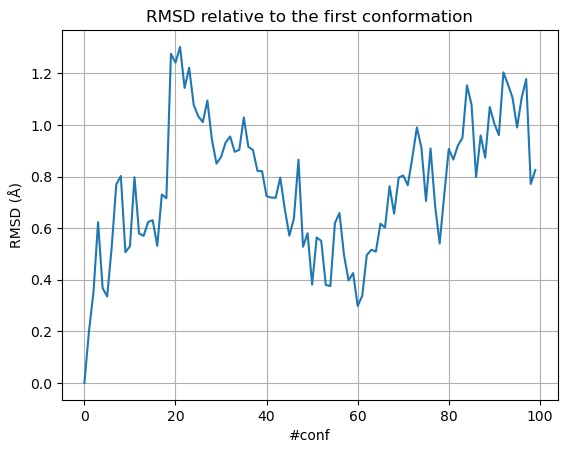

In [ ]:
# Load the topology and trajectory
trajectory_file = 'data/brad_dry.nc'
topology_file = 'data/topology_dry.prmtop'

traj = pt.load(trajectory_file, topology_file)

# Calculate the RMSD with Cα atoms using the first frame as reference
rmsd_data = pt.rmsd(traj, mask='@CA', ref=0)

# Plot the RMSD results
plt.plot(rmsd_data)
plt.xlabel("#conf")
plt.ylabel("RMSD (Å)")
plt.title("RMSD relative to the first conformation")
plt.grid(True)
plt.show()


**The RMSD** (Root Mean Square Deviation) is a measure of the average deviation between a molecule's initial structure (reference) and its successive conformations throughout a simulation.

In this analysis, the initial conformation (frame 0) has an RMSD of 0 Å (angstrom), indicating that the structure is identical to the reference. At conformation 100, the RMSD reaches 0.8 Å, indicating a significant departure from the initial structure and exploration of the conformational space. This initial phase is often associated with structural rearrangements due to internal adjustments (such as van der Waals interactions, hydrogen bonds) and the external conditions of the simulation (solvent, temperature, etc.).

The increase in RMSD to 0.8 Å suggests that the molecule explores alternative conformations before stabilizing within a set of relatively close structures. If this value stabilizes over the course of the simulation, it indicates that a dynamic equilibrium has been reached, with fluctuations around this mean value being characteristic of stable molecular dynamics.
Thus, an RMSD of 0.8 Å at conformation 100 indicates not only a structural rearrangement but also a point where the molecule may have reached a relatively stable state, depending on the simulation conditions.

To gain a deeper understanding of conformational changes and molecular flexibility, employing techniques like Principal Component Analysis (PCA) or conformational clustering would be beneficial. Further analysis, encompassing the radius of gyration (Rg) and local interactions (such as hydrogen bonds), could corroborate whether the molecule adopts a more flexible conformation or undergoes a significant conformational transition.

Text(0, 0.5, 'RMSF(Å)')

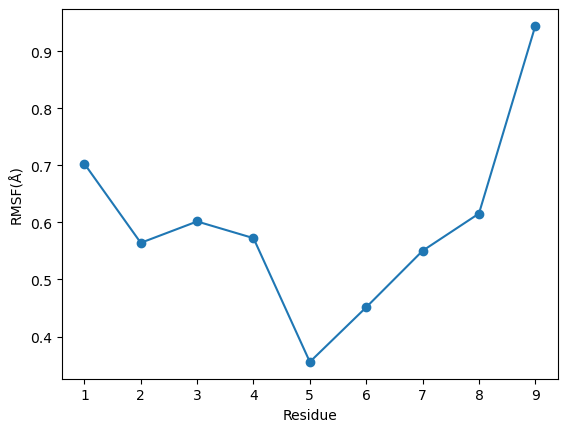

In [ ]:
rmsf_data=pt.rmsf(traj, mask='@CA')
res=range(1,10)
plt.plot(res, rmsf_data.T[1], marker="o")
plt.xlabel('Residue')
plt.ylabel('RMSF(Å)')

**RMSF** (The Root Mean Square Fluctuation) is a key indicator of the flexibility of protein residues during a molecular dynamics simulation.

A high RMSF reflects a high mobility of a residue, while a low RMSF indicates that it is more rigid. In the presented graph, the evolution of RMSF as a function of residues shows significant heterogeneity in the movements, which is typical for proteins where some regions are flexible and others are more rigid. For example, residues such as numbers 1, 8, and 9, with high RMSF, are often associated with loops or solvent-exposed regions, allowing dynamic conformational changes, such as the opening and closing of active sites or the reorientation of certain structures. In contrast, residues like 5 and 6, with low RMSF, are located in structured regions, such as alpha-helices or beta-sheets, which provide stability to the protein. Analyzing the RMSF profile, combined with the three-dimensional structure, helps correlate the flexibility of certain regions with their biological role, such as active sites, which are often characterized by greater flexibility to interact with substrates. However, factors such as simulation duration, protein size, and temperature influence the results. A simulation that is too short or an inappropriate temperature may distort the observed fluctuations.


In conclusion, the RMSF analysis provides crucial information about the protein's dynamics, helping to better understand its biological functions and behavior under different conditions.


Radius of gyration for each frame: [5.03758475 4.93677123 5.08666801 ... 5.50761599 5.32453969 5.26550781]


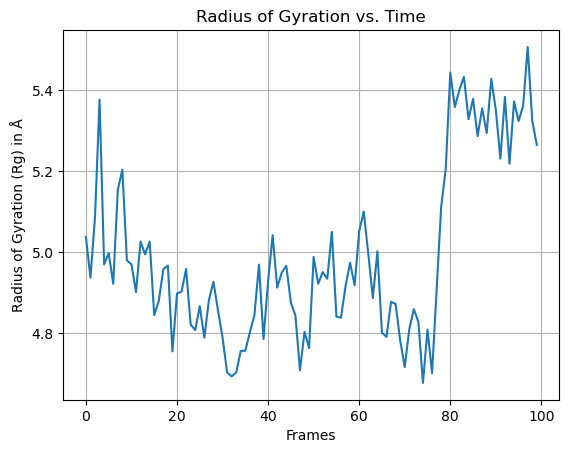

In [ ]:
# Load the trajectory and topology files
# Replace 'production.nc' and 'brad.prmtop' with your files
traj = pt.load('data/brad_dry.nc', top='data/topology_dry.prmtop')

# Calculate the radius of gyration (Rg) for the Cα atoms
rgyr = pt.radgyr(traj, mask='@CA')  # "@CA" selects only the Cα atoms

# Display the results table
print("Radius of gyration for each frame:", rgyr)

# Plot the radius of gyration vs. time
plt.plot(rgyr)
plt.xlabel("Frames")
plt.ylabel("Radius of Gyration (Rg) in Å")
plt.title("Radius of Gyration vs. Time")
plt.grid(True)
plt.show()

The analysis of **the radius of gyration** trajectory reveals key insights into the conformational dynamics of the molecule. This metric, quantifying the molecule's compactness by averaging atomic distances from its center of mass, exhibits fluctuations indicative of its conformational plasticity. The lack of a consistent trend (monotonic increase or decrease) points towards a dynamic equilibrium, where the molecule oscillates around a preferred conformation without undergoing drastic changes in its overall size. Local maxima and minima in the radius of gyration likely correspond to transient conformational transitions, such as the opening and closing of active sites or rearrangements within specific regions. This suggests functional flexibility, as these fluctuations could be crucial for the molecule's biological activity. For instance, a stable average radius of gyration of 5 Å with superimposed fluctuations could represent a predominantly compact state, while pronounced variations, particularly between frames 20 and 80, might signify conformational rearrangements involving flexible domains or shifts in intermolecular interactions.

 A slight increase in the amplitude of radius of gyration fluctuations towards the end of the simulation hints at a potential stabilization of the molecule in a more open or dynamic configuration.

Initial position of the first residue: [21.72023773 24.83184433 17.24601936]
Initial position of the last residue: [21.04645157 24.05210304 28.41918373]
Final position of the first residue: [19.46220398 22.24478531 15.00750446]
Final position of the last residue: [19.36976242 21.7096405  26.60661507]


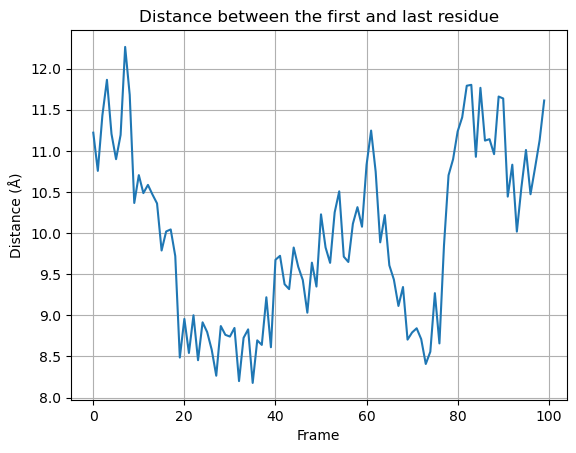

In [ ]:
# Load the topology and trajectory
topology_file = "data/topology_dry.prmtop"
trajectory_file = "data/brad_dry.nc"  # Ensure the format is valid

traj = pt.load(trajectory_file, top=topology_file)

# Specify the initial and final residues (Amber indices start from 1)
first_residue = 1  # Residue 0 in your topology
last_residue = 9   # Residue 8 in your topology

# Calculate the initial and final positions of the residues
first_position_initial = traj.xyz[0, traj.top.select(f":{first_residue}@CA")[0]]
last_position_initial = traj.xyz[0, traj.top.select(f":{last_residue}@CA")[0]]

first_position_final = traj.xyz[-1, traj.top.select(f":{first_residue}@CA")[0]]
last_position_final = traj.xyz[-1, traj.top.select(f":{last_residue}@CA")[0]]

# Display the initial and final positions
print(f"Initial position of the first residue: {first_position_initial}")
print(f"Initial position of the last residue: {last_position_initial}")
print(f"Final position of the first residue: {first_position_final}")
print(f"Final position of the last residue: {last_position_final}")

# Calculate the distance between the first and last Cα atoms for each frame
distance = pt.distance(traj, f":{first_residue}@CA :{last_residue}@CA")

# Plot the distance curve
plt.plot(distance)
plt.xlabel("Frame")
plt.ylabel("Distance (Å)")
plt.title("Distance between the first and last residue")
plt.grid(True)
plt.show()


**The analysis of the distance between the first and last residues of a protein** during a molecular dynamics simulation provides crucial insights into the flexibility and dynamics of the structure.

The observed fluctuations in the graph indicate significant mobility in the region between the protein’s termini, suggesting that this area is flexible and capable of undergoing conformational changes. The absence of a clear trend, meaning there is no systematic increase or decrease in the distance throughout the simulation, could imply that there is no major global conformational change in the protein, but rather local variations.

These fluctuations may be linked to events such as the formation or breaking of hydrogen bonds, or conformational adjustments involving the residues between the ends of the protein. For instance, in the case of a globular protein, these fluctuations might reflect the presence of a flexible loop connecting the two ends, while for a fibrous protein, they could be due to local bending of the polypeptide chain. Based on specific values of the end-to-end distance, such as at the beginning of the simulation (frame 0), where the distance is 11 Å, and at the end of the simulation (frame 100), where the distance is about 11.5 Å, we can interpret that the protein has slightly extended its conformation during the simulation. This small increase in distance could be linked to greater flexibility in the terminal regions of the protein, interactions with the solvent, or thermal fluctuations.

Additionally, transient events, such as a rapid change in distance between two frames, could correspond to more significant conformational changes, such as the opening or closing of an active site. This analysis should be complemented by correlating it with other simulation results, such as RMSD or RMSF, and considering experimental conditions (temperature, ionic strength, etc.) as well as the biological context of the protein.

In summary, the analysis of the end-to-end distance provides insights into molecular dynamics and helps interpret the flexibility and conformational changes associated with important biological processes.

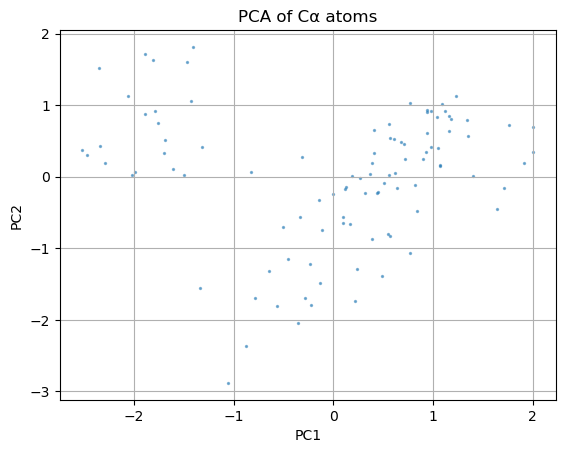

In [ ]:
# Load the topology and trajectory
trajectory_file = 'data/brad_dry.nc'
topology_file = 'data/topology_dry.prmtop'

traj = pt.load(trajectory_file, topology_file)

# Perform PCA analysis on Cα atoms
pca_data = pt.pca(traj, mask='@CA', n_vecs=2)

# Retrieve the first two principal components
pca1 = pca_data[0][0]  # First principal component (PC1)
pca2 = pca_data[0][1]  # Second principal component (PC2)

# Plot the PCA results
plt.scatter(pca1, pca2, s=2, alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title("PCA of Cα atoms")
plt.grid(True)
plt.show()


**PCA** (Principal Component Analysis) is a statistical method for dimensionality reduction that condenses data information while preserving its variance as much as possible. In molecular dynamics, PCA is commonly applied to the Cartesian coordinates of a protein’s atoms, particularly the alpha carbon (Ca) atoms, to highlight the most significant collective motion modes. This approach enables visualization of the protein's global movements in a reduced space, typically defined by the first two principal components (PC1 and PC2), which capture the majority of the variance observed in the data.

The dispersion of points in the factorial plot obtained through PCA provides a direct indication of the protein’s conformational flexibility. A large dispersion suggests high mobility, while a concentration of points around the origin indicates a more rigid, less flexible structure. Points far from the origin, representing conformations distant from the mean, highlight significant displacements, whereas points aligned along a principal axis indicate dominant collective motions, often associated with important conformational changes. The appearance of distinct clusters of points can also suggest the existence of multiple stable conformational states that the protein explores during the simulation, indicating discontinuous conformational dynamics.

In interpreting a PCA plot, the dispersion and orientation of points along the PC1 and PC2 axes provide valuable insights into specific protein movements, such as the opening or closing of an active site or the rotation of a domain. The absence of well-defined clusters in the explored conformational space suggests that the protein does not adopt discrete states but rather explores a continuous conformational space. To deepen the interpretation, it would be useful to calculate the variance explained by the first two principal components, which would quantify the importance of these movements in the protein's overall dynamics.

Additionally, correlating these movement modes with functional properties, such as enzymatic activity or binding to other molecules, would provide a better understanding of their role in the protein’s biological function. Finally, PCA could be combined with other techniques, such as normal mode analysis, for a more in-depth exploration of the protein's vibrations and flexibility modes, thus offering a more complete view of its molecular dynamics. In conclusion, PCA proves to be an essential tool in studying protein dynamics, helping to identify dominant collective motions and uncover global trends of flexibility and conformation within the protein structure.


Text(0, 0.5, 'Distance (Å)')

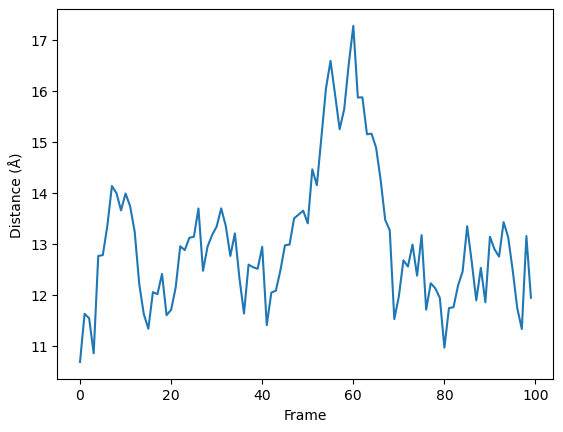

In [ ]:
distance_data=pt.distance(traj, ':1@CZ :9@CZ')
plt.plot(distance_data)
plt.xlabel('Frame')
plt.ylabel('Distance (Å)')

**The analysis of distance evolution** in molecular dynamics simulations is a crucial tool for understanding the movements and conformational transitions within biomolecular systems. This type of graph, which tracks the evolution of a specific distance (e.g., between two atoms, the center of mass of two residues, or between a solvent molecule and an active site) over simulation time, reveals key information about the flexibility and local dynamics of a protein or complex.

The fluctuations observed in this graph can indicate significant conformational movements, often associated with functional transitions such as the opening or closing of an active site or the rearrangement of a protein-protein interface. For example, an increasing distance between two atoms involved in an active site may signal a major conformational change, such as a deformation in the protein structure, allowing ligand access or altering enzymatic catalysis. Peaks and troughs in the curve can be interpreted as discrete events, such as the breaking or formation of hydrogen bonds, indicating the protein’s chemical reactivity in its environment. A numerical example, where the distance increases from 12 Å to 16 Å and then returns to 12 Å at the end of the simulation, may suggest a dynamic process of bending or adjustment in conformation, potentially related to active site function.

However, this analysis must be contextualized based on the nature of the involved atoms, the region of the protein where these atoms reside (e.g., in a flexible or rigid region), ongoing molecular interactions (especially with solvents or ligands), and other essential simulation parameters such as variations in RMSD (Root Mean Square Deviation), RMSF (Root Mean Square Fluctuation), and potential energies. Integrating these data not only enhances our understanding of molecular movements but also helps interpret the underlying mechanisms of the protein's biological function, considering factors like temperature, ionic strength, and other simulated conditions that can influence the results.

In summary, such a detailed analysis of distances in MD simulations is a valuable tool for unraveling dynamic biological processes, but it requires nuanced interpretation and consideration of the overall simulated system.


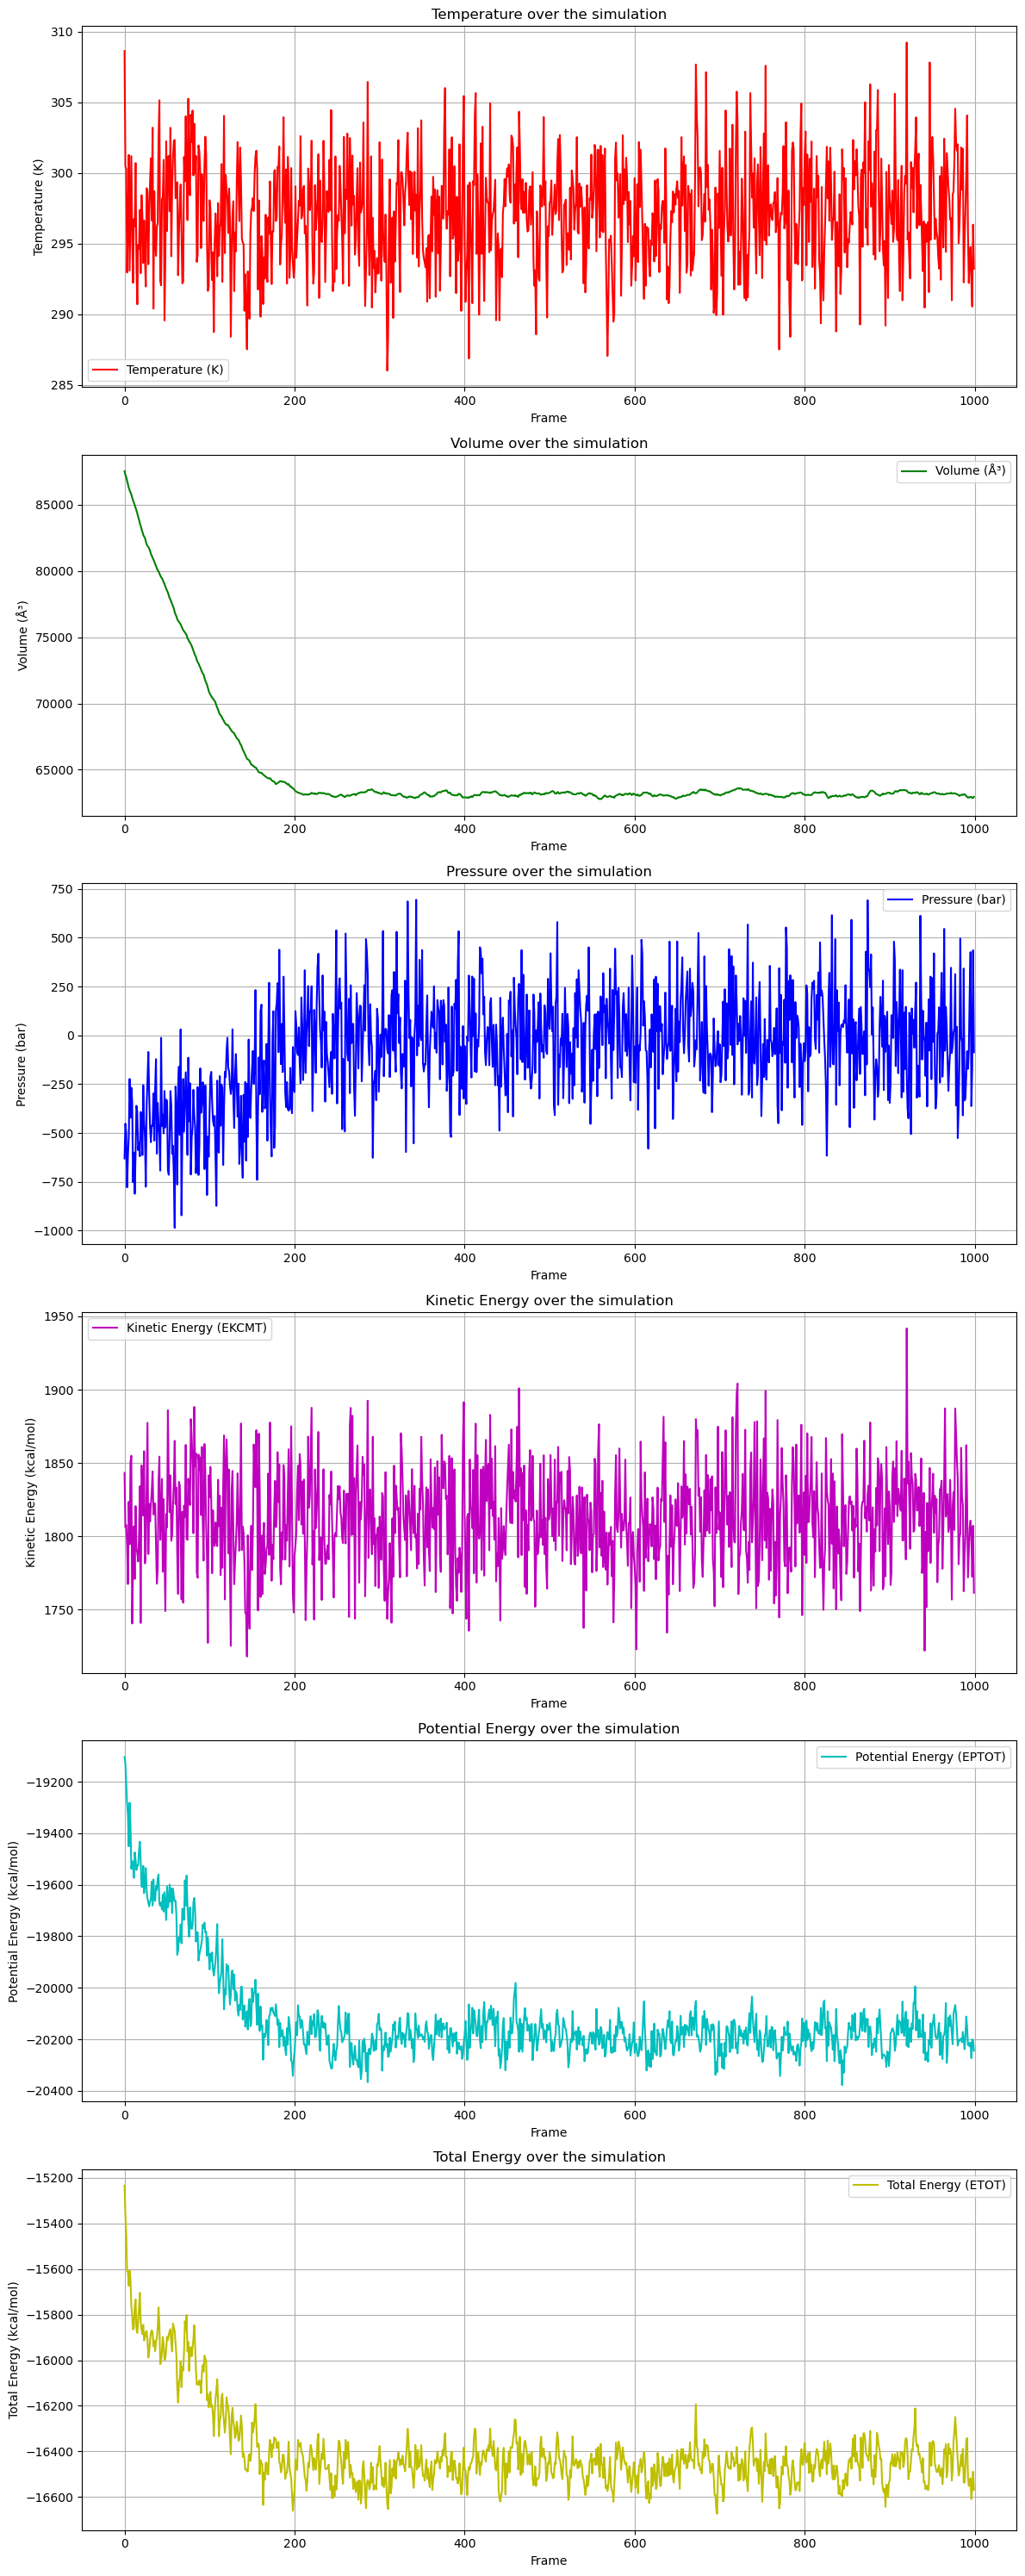

In [ ]:
# List of files to process
files = [
    'summary.TEMP', 'summary.VOLUME', 'summary.PRES', 'summary.EKCMT',
    'summary.EPTOT', 'summary.ETOT'
]

# Function to read data from a file and extract relevant columns
def read_data(file_path, column_index=1):
    """
    Read data from a text file and extract a specific column.
    :param file_path: path to the file
    :param column_index: index of the column to extract (0 for the first column, 1 for the second, etc.)
    :return: list of extracted values
    """
    data = []
    try:
        with open(file_path, 'r') as file:
            for line in file:
                try:
                    columns = line.split()  # Split by space
                    if len(columns) > column_index:
                        data.append(float(columns[column_index]))  # Convert to float
                except ValueError:
                    continue  # If conversion fails, skip to the next line
    except FileNotFoundError:
        print(f"The file {file_path} was not found.")
    return data

# Dictionary to store extracted results
data_dict = {}

# Read data from each file
for file in files:
    data_dict[file] = read_data(file, 1)  # Extract the 2nd column (index 1)

# Plot the results
fig, axs = plt.subplots(6, 1, figsize=(12, 30))  # Adjusted for 6 subplots

# Plot temperature (summary.TEMP)
if 'summary.TEMP' in data_dict:
    axs[0].plot(data_dict['summary.TEMP'], label='Temperature (K)', color='r')
    axs[0].set_title('Temperature over the simulation')
    axs[0].set_xlabel('Frame')
    axs[0].set_ylabel('Temperature (K)')
    axs[0].grid(True)
    axs[0].legend()

# Plot volume (summary.VOLUME)
if 'summary.VOLUME' in data_dict:
    axs[1].plot(data_dict['summary.VOLUME'], label='Volume (Å³)', color='g')
    axs[1].set_title('Volume over the simulation')
    axs[1].set_xlabel('Frame')
    axs[1].set_ylabel('Volume (Å³)')
    axs[1].grid(True)
    axs[1].legend()

# Plot pressure (summary.PRES)
if 'summary.PRES' in data_dict:
    axs[2].plot(data_dict['summary.PRES'], label='Pressure (bar)', color='b')
    axs[2].set_title('Pressure over the simulation')
    axs[2].set_xlabel('Frame')
    axs[2].set_ylabel('Pressure (bar)')
    axs[2].grid(True)
    axs[2].legend()

# Plot kinetic energy (summary.EKCMT)
if 'summary.EKCMT' in data_dict:
    axs[3].plot(data_dict['summary.EKCMT'], label='Kinetic Energy (EKCMT)', color='m')
    axs[3].set_title('Kinetic Energy over the simulation')
    axs[3].set_xlabel('Frame')
    axs[3].set_ylabel('Kinetic Energy (kcal/mol)')
    axs[3].grid(True)
    axs[3].legend()

# Plot potential energy (summary.EPTOT)
if 'summary.EPTOT' in data_dict:
    axs[4].plot(data_dict['summary.EPTOT'], label='Potential Energy (EPTOT)', color='c')
    axs[4].set_title('Potential Energy over the simulation')
    axs[4].set_xlabel('Frame')
    axs[4].set_ylabel('Potential Energy (kcal/mol)')
    axs[4].grid(True)
    axs[4].legend()

# Plot total energy (summary.ETOT)
if 'summary.ETOT' in data_dict:
    axs[5].plot(data_dict['summary.ETOT'], label='Total Energy (ETOT)', color='y')
    axs[5].set_title('Total Energy over the simulation')
    axs[5].set_xlabel('Frame')
    axs[5].set_ylabel('Total Energy (kcal/mol)')
    axs[5].grid(True)
    axs[5].legend()

plt.tight_layout()
plt.show()

**Temperature :**

The temperature evolution graph during a molecular dynamics simulation provides insights into the system’s thermal behavior over time, with each point representing the temperature at a specific moment during the simulation. Fluctuations around a mean value suggest that the thermostat controlling the temperature is not perfectly effective, leading to energy exchanges between the system and the thermostat. However, the relatively stable average temperature indicates that the thermostat is successfully maintaining the target temperature. A deeper analysis of the fluctuations reveals the efficiency of the thermostat, with smaller fluctuations indicating better temperature control. For instance, fluctuations of ±2 K around a 300 K mean temperature would suggest stability within a range of 298–302 K. Abrupt temperature changes may signal significant conformational shifts or numerical issues, such as integration instabilities. Temperature control is crucial for simulating realistic experimental conditions, as excessively high or low temperatures can distort the system's behavior, potentially leading to protein denaturation or slowed dynamics.

To further refine the analysis, comparing temperature trends across different simulations or correlating temperature variations with other observables, like protein conformational changes, would offer additional insights. Ultimately, monitoring temperature during molecular dynamics simulations is essential for ensuring the reliability and interpretability of the results.

**volume :**

The evolution of volume during the protein simulation provides insights into its structural dynamics over time. Starting with an initial volume of approximately 88000 Å³, a rapid decrease is observed, suggesting a transition from an initially disordered or extended state to a more compact conformation. This phenomenon is typically associated with the protein folding phase, where it stabilizes into a well-defined three-dimensional structure. After this initial phase, the volume fluctuates around an average value, indicating an equilibration phase where the protein reaches a stable conformation. Thermal fluctuations around this average are characteristic of a thermodynamic equilibrium system, resulting from random atomic movements and interactions with the solvent. By the end of the simulation, the volume reaches approximately 64000 Å³, suggesting that the protein has reached a more compact stable state while maintaining some internal dynamics. These fluctuations may be related to lateral movements of side chains, adjustments in secondary structure, or water exchanges with the solvent. Larger volume variations may indicate rare events, such as significant conformational changes, like the opening or closing of pockets in the protein, which could have functional implications, such as modulation of biological activity or interaction with ligands.

**Pressure :**

The pressure evolution graph in molecular dynamics simulations offers essential insights into the system's thermodynamic behavior. Fluctuations around a near-zero mean value indicate significant thermal fluctuations, which are expected in such simulations, reflecting the inherent random motion of atoms. The absence of a clear upward or downward trend in pressure suggests that the system has reached thermodynamic equilibrium, with no net change in pressure over time. Negative pressure values, though initially surprising, are explained by the dominance of attractive molecular forces over repulsive ones, leading to system compression. These pressure fluctuations arise from atomic thermal movements, intermolecular interactions such as van der Waals forces and hydrogen bonding, and the thermostat used to maintain system temperature, which can also contribute to pressure variations.

Overall, analyzing pressure provides valuable information on the thermodynamic stability, molecular interactions, and structural properties of the system, enhancing our understanding of its behavior in the simulation.

**Kinetic energy  :**

The analysis of the evolution of kinetic energy during a molecular dynamics simulation reveals significant fluctuations around a mean value, which is typical of the random motion of atoms and is directly related to the system's temperature. These fluctuations are caused by atomic collisions and kinetic energy transfers, with variations introduced by the thermostat used to control temperature. Despite these fluctuations, the stability of the mean value indicates effective temperature regulation, which is essential for maintaining thermodynamic equilibrium. Kinetic energy, being directly proportional to temperature, serves as a crucial measure to verify thermal control of the system. A numerical example, where the average kinetic energy is 1800 kcal/mol, shows that the temperature fluctuates around this value, with an amplitude of ±50 kcal/mol, thus confirming stable thermal control throughout the simulation.

This stable kinetic energy behavior indicates that the system is at thermodynamic equilibrium, which is fundamental to ensuring the reliability of the simulation results.

**Potential energy :**

The analysis of the potential energy evolution in a molecular dynamics simulation reveals significant fluctuations around a negative mean value, which is typical of the random movements of atoms and continuous changes in interatomic distances. Initially, the potential energy decreases as the system undergoes energy minimization to achieve a more stable conformation. Following this phase, the potential energy stabilizes around a relatively steady value, indicating that the system has reached equilibrium. The negative value of the potential energy is a result of the convention used in molecular dynamics, where the most stable state corresponds to the minimum energy, typically a negative value due to attractive atomic interactions such as covalent bonds, hydrogen bonds, and van der Waals forces. Fluctuations in potential energy are driven by thermal movements of atoms, vibrational modes of chemical bonds, and conformational changes. For example, if the average potential energy is -19,500 kcal/mol with fluctuations of ±200 kcal/mol, this means the potential energy varies between -19,700 kcal/mol and -19,300 kcal/mol. A decrease in potential energy generally reflects an increase in system stability, bond formation, and atom proximity, while an increase in potential energy signifies a reduction in stability, bond breaking, and atom separation.

This analysis provides essential insights into the stability of the system, atomic interactions, and conformational changes, crucial for understanding the dynamics of the molecular system.

**Total Energy :**

The analysis of the total energy evolution of a molecular system during a molecular dynamics simulation, which is the sum of kinetic and potential energy, reveals significant fluctuations around a negative average value. These fluctuations are due to the random thermal movements of atoms, variations in interatomic distances, and molecular vibrations. Initially, a decrease in total energy is observed, corresponding to the energy minimization phase where the system seeks to reach a stable conformation, followed by stabilization around a relatively stable average value, indicating that the system has reached equilibrium. The total energy is often negative due to the convention where the potential energy is defined such that the most stable state corresponds to a minimum energy. Additional fluctuations can be caused by significant conformational changes. For example, if the system's average total energy is -15,500 kcal/mol with a fluctuation amplitude of ±200 kcal/mol, this indicates that the total energy oscillates between -15,700 and -15,300 kcal/mol, reflecting variations related to system stability, bond formation or rupture, and changes in interatomic distances. A decrease in total energy, becoming more negative, generally indicates system stabilization and bond formation, while an increase, becoming less negative, signals a loss of stability and atom separation.

This analysis provides crucial information about the system's stability, atomic interactions, and conformational changes, and allows for further study by correlating energy variations with other parameters, comparing results with other simulations, and considering the biological context of the simulated molecule.


